In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
from boolean_analysis import calculate_fourier_transform_matrix, parity_of_1s
import pandas as pd
from tqdm import tqdm
import pickle
from boolean_fourier_learner import BooleanFourierLearner
from pathlib import Path
import lzma
import parse
from spin_lattices import KagomeLattice
from utils import make_unpacked_configurations

%matplotlib inline

In [3]:
learners = {}
for file in Path("kagome24").glob("fourier-learner-*.pickle.lz"):
    J, i = parse.search("fourier-learner-{:f}-{:d}.pickle.lz", str(file)).fixed
    with lzma.open(file) as f:
        learners[J, i] = pickle.load(f)

In [4]:
learners_ser = (
    pd.DataFrame(dict(learner=learners))
    .reset_index()
    .rename(columns={"level_0": "J", "level_1": "stochastic_iterations"})
).set_index(["J", "stochastic_iterations"])["learner"]

In [5]:
learners_ser

J    stochastic_iterations
0.0  0                        <boolean_fourier_learner.BooleanFourierLearner...
     100                      <boolean_fourier_learner.BooleanFourierLearner...
     200                      <boolean_fourier_learner.BooleanFourierLearner...
     300                      <boolean_fourier_learner.BooleanFourierLearner...
     400                      <boolean_fourier_learner.BooleanFourierLearner...
     500                      <boolean_fourier_learner.BooleanFourierLearner...
     600                      <boolean_fourier_learner.BooleanFourierLearner...
     700                      <boolean_fourier_learner.BooleanFourierLearner...
     800                      <boolean_fourier_learner.BooleanFourierLearner...
     900                      <boolean_fourier_learner.BooleanFourierLearner...
     1000                     <boolean_fourier_learner.BooleanFourierLearner...
     1100                     <boolean_fourier_learner.BooleanFourierLearner...
0.8  0       

In [6]:
learners_ser[0].to_frame().assign(
    max_higher_term=lambda x: [
        np.abs(learner.get_coeffs_df().iloc[2:]["coeff"]).max()
        for learner in x["learner"]
    ]
)

,learner,max_higher_term
stochastic_iterations,,
0,<boolean_fourier_learner.BooleanFourierLearner...,0.000050
100,<boolean_fourier_learner.BooleanFourierLearner...,0.000646
200,<boolean_fourier_learner.BooleanFourierLearner...,0.001190
300,<boolean_fourier_learner.BooleanFourierLearner...,0.001746
400,<boolean_fourier_learner.BooleanFourierLearner...,0.002450
500,<boolean_fourier_learner.BooleanFourierLearner...,0.002946
600,<boolean_fourier_learner.BooleanFourierLearner...,0.003594
700,<boolean_fourier_learner.BooleanFourierLearner...,0.004104
800,<boolean_fourier_learner.BooleanFourierLearner...,0.004784


In [7]:
100 * 2000 / (2**24)

0.011920928955078125

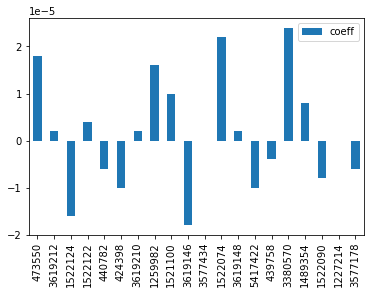

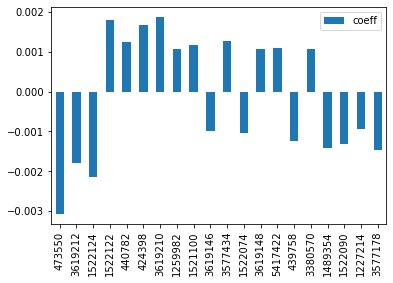

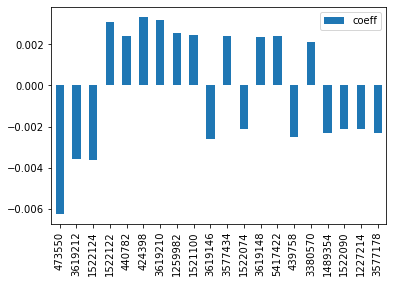

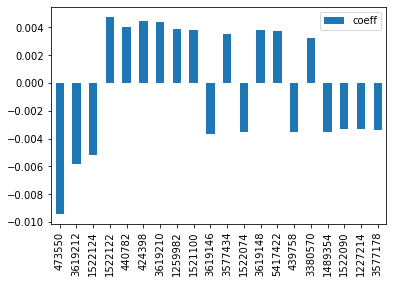

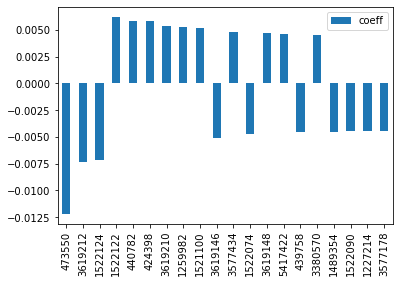

In [8]:
index = learners_ser[0.8, 2000].get_coeffs_df().iloc[:20].index
for i in range(0, 2500, 500):
    learners_ser[0.8, i].get_coeffs_df().loc[index].plot.bar()

In [9]:
lat = KagomeLattice(width=2, height=4)

In [10]:
type(learners_ser[0.8, 2000].get_coeffs_df().index[0])

numpy.uint64

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

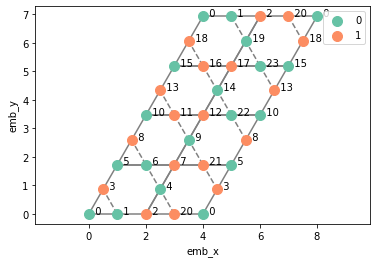

In [11]:
lat.plot(spins=int(learners_ser[0.8, 1000].get_coeffs_df().index[2]))

In [12]:
import importlib

In [13]:
kagome_24_fourier = importlib.import_module("kagome-24-fourier")
fourier_basis = kagome_24_fourier.fourier_basis
system = kagome_24_fourier.system

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.8-True-1-1.pickle
Ground state energy is -40.5183420067


In [14]:
from heisenberg_hamiltonians import batched_state_info_df

state_info_df = batched_state_info_df(
    fourier_basis, np.arange(2**system.number_spins, dtype="uint64")
)

In [15]:
multiplicities = (
    state_info_df.reset_index()
    .rename(columns={"index": "subset"})
    .groupby("representative")
    .size()
)

In [16]:
learners_ser[0.8, 1000].get_coeffs_df().assign(
    multiplicities=multiplicities
).iloc[:10]

,coeff,multiplicities
473550,-0.006276,4
1522124,-0.003608,16
3619212,-0.003590,8
424398,0.003352,16
3619210,0.003164,16
1522122,0.003082,16
3619146,-0.002614,16
7809356,-0.002584,8
1259982,0.002542,16
16083546,0.002522,4


In [17]:
multiplicities.value_counts()

16    1041432
8       14022
4         506
2          48
1           8
dtype: int64

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

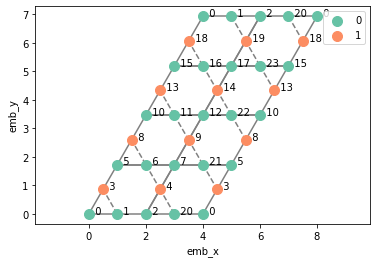

In [18]:
lat.plot(spins=811800)

In [19]:
from boolean_analysis import calculate_fourier_transform_matrix

In [20]:
def expand_fourier_coeffs(coeffs, fourier_basis, number_spins):
    state_info_df = batched_state_info_df(
        fourier_basis, np.arange(2**number_spins, dtype="uint64")
    )
    return state_info_df.join(coeffs, on="representative")["coeff"].dropna()

In [21]:
def predict(coeffs, x, number_spins):
    transform_matrix = calculate_fourier_transform_matrix(
        states=x,
        subsets=np.array(coeffs.index, dtype="uint64"),
        number_spins=number_spins,
        show_progress=True,
    )
    return transform_matrix @ coeffs

In [22]:
from heisenberg_hamiltonians import HeisenbergJ1J2

In [23]:
J2 = 0.8
system = system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=J2, use_symmetries=True
)
system.get_eigenstates()

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.8-True-1-1.pickle
Ground state energy is -40.5183420067


(array([-40.51834201]),
 array([[ 8.36163038e-08],
        [ 1.13414544e-07],
        [ 1.79331566e-08],
        ...,
        [-8.66655973e-03],
        [-1.17282633e-02],
        [ 3.99580256e-03]]))

In [59]:
prediction = predict(
    expand_fourier_coeffs(
        learners_ser[J2, 100].get_coeffs_df().iloc[:20],
        fourier_basis,
        system.number_spins,
    ),
    system.canonical_basis.states,
    system.number_spins,
)

100%|██████████| 24/24 [02:44<00:00,  6.86s/it]


In [60]:
system.ground_state

array([ 8.36163038e-08,  1.13414544e-07,  1.79331566e-08, ...,
       -8.66655973e-03, -1.17282633e-02,  3.99580256e-03])

In [61]:
(system.get_df_ground_state(canonical_basis=True)["amplitude"] ** 2).sum()

0.9999999999999987

In [62]:
(
    np.sign(prediction)
    * system.get_df_ground_state(canonical_basis=True)["amplitude"]
    * system.get_df_ground_state(canonical_basis=True)["eigenstate_coeff"]
).sum()

0.2006379913870131

In [63]:
sample = np.random.choice(
    system.canonical_basis.states, replace=False, size=10000
)

In [64]:
prediction = predict(
    expand_fourier_coeffs(
        learners_ser[J2, 100].get_coeffs_df().iloc[:3000],
        fourier_basis,
        system.number_spins,
    ),
    sample,
    system.number_spins,
)

100%|██████████| 24/24 [00:52<00:00,  2.20s/it]


In [65]:
expand_fourier_coeffs(
    learners_ser[J2, 100].get_coeffs_df().iloc[:2000],
    fourier_basis,
    system.number_spins,
).shape[0] / 2**24

0.0018377304077148438

In [66]:
(
    np.sign(prediction)
    * system.get_df_ground_state(canonical_basis=True).loc[sample]["amplitude"]
    * system.get_df_ground_state(canonical_basis=True).loc[sample][
        "eigenstate_coeff"
    ]
).sum() / (
    system.get_df_ground_state(canonical_basis=True).loc[sample][
        "eigenstate_coeff"
    ]
    ** 2
).sum()

0.9888376149135104

In [58]:
100 * 100 / (2.7 * 10**6)

0.003703703703703704